# PCA + Clustering Overview

This notebook builds a compact multivariate analysis workflow for the Kepler dataset:
- data merge and feature preparation
- PCA for dimensionality reduction and interpretation
- clustering for group discovery and profile summaries

The figures are intended for thesis narrative and can be reused directly.


In [11]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.mixture import GaussianMixture

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = Path('/Users/Zhuanz/Documents/Dissertation')

DATA_ROOT = PROJECT_ROOT / 'data' / 'kepler'

PALETTE = ['#4C72B0', '#55A868', '#C44E52', '#8172B3', '#64B5CD', '#DD8452', '#937860']
sns.set_theme(
    context='paper',
    style='whitegrid',
    font_scale=1.1,
    rc={
        'axes.spines.top': False,
        'axes.spines.right': False,
        'grid.linestyle': '--',
        'grid.alpha': 0.3,
    },
)
sns.set_palette(PALETTE)
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42


## Data loading

Read overview and baseline results, then merge by `kic`.


In [12]:
def read_csv_optional(path: Path) -> pd.DataFrame:
    if path.exists():
        return pd.read_csv(path)
    print(f'[WARN] Missing file: {path}')
    return pd.DataFrame()

lc_path = DATA_ROOT / 'lc_overview.csv'
baseline_path = DATA_ROOT / 'baseline_periods_ls_acf.csv'
sample_path = DATA_ROOT / 'mcquillan2014_sample.csv'
catalog_path = DATA_ROOT / 'mcquillan2014_catalog.csv'

df_lc = read_csv_optional(lc_path)
df_base = read_csv_optional(baseline_path)
df_sample = read_csv_optional(sample_path)
df_cat = read_csv_optional(catalog_path)

print('lc_overview:', df_lc.shape)
print('baseline:', df_base.shape)
print('sample:', df_sample.shape)
print('catalog:', df_cat.shape)

if df_lc.empty:
    raise RuntimeError('lc_overview.csv is required for this notebook.')

df = df_lc.copy()
if not df_base.empty and 'kic' in df_base.columns:
    keep_cols = [
        c for c in [
            'kic', 'prot_label', 'prot_ls', 'prot_acf', 'prot_gps', 'prot_qpgp'
        ] if c in df_base.columns
    ]
    df = df.merge(df_base[keep_cols], on='kic', how='left')

if not df_cat.empty and 'kic' in df_cat.columns:
    keep_cols = [c for c in ['kic', 'prot', 'teff'] if c in df_cat.columns]
    df = df.merge(df_cat[keep_cols], on='kic', how='left', suffixes=('', '_cat'))

print('merged:', df.shape)


lc_overview: (909, 9)
baseline: (909, 11)
sample: (1000, 3)
catalog: (34030, 3)
merged: (909, 16)


## Feature preparation

Create log-transformed flux features and filter columns by missing rate.


In [13]:
df = df.copy()

if 'flux_std' in df.columns and 'flux_median' in df.columns:
    df['flux_cv'] = df['flux_std'] / df['flux_median'].abs()

eps = 1e-8
if 'flux_median' in df.columns:
    df['log_flux_median'] = np.log10(df['flux_median'].abs().clip(lower=eps))
if 'flux_std' in df.columns:
    df['log_flux_std'] = np.log10(df['flux_std'].abs().clip(lower=eps))
if 'flux_cv' in df.columns:
    df['log_flux_cv'] = np.log10(df['flux_cv'].clip(lower=eps))

candidate_features = [
    'n_points',
    'time_span_days',
    'cadence_minutes',
    'log_flux_median',
    'log_flux_std',
    'log_flux_cv',
    'prot',
    'teff',
    'prot_label',
    'prot_ls',
    'prot_acf',
    'prot_gps',
    'prot_qpgp',
]

candidate_features = [c for c in candidate_features if c in df.columns]
missing_rate = df[candidate_features].isna().mean().sort_values(ascending=False)
missing_rate


prot_acf           0.808581
prot_gps           0.012101
cadence_minutes    0.000000
time_span_days     0.000000
n_points           0.000000
log_flux_std       0.000000
log_flux_median    0.000000
log_flux_cv        0.000000
prot               0.000000
prot_label         0.000000
teff               0.000000
prot_ls            0.000000
prot_qpgp          0.000000
dtype: float64

In [14]:
max_missing = 0.3
selected_features = [c for c in candidate_features if missing_rate.get(c, 1.0) <= max_missing]

print('selected features:', selected_features)

X_raw = df[selected_features]


selected features: ['n_points', 'time_span_days', 'cadence_minutes', 'log_flux_median', 'log_flux_std', 'log_flux_cv', 'prot', 'teff', 'prot_label', 'prot_ls', 'prot_gps', 'prot_qpgp']


## PCA

Impute missing values, standardize features, and fit PCA.


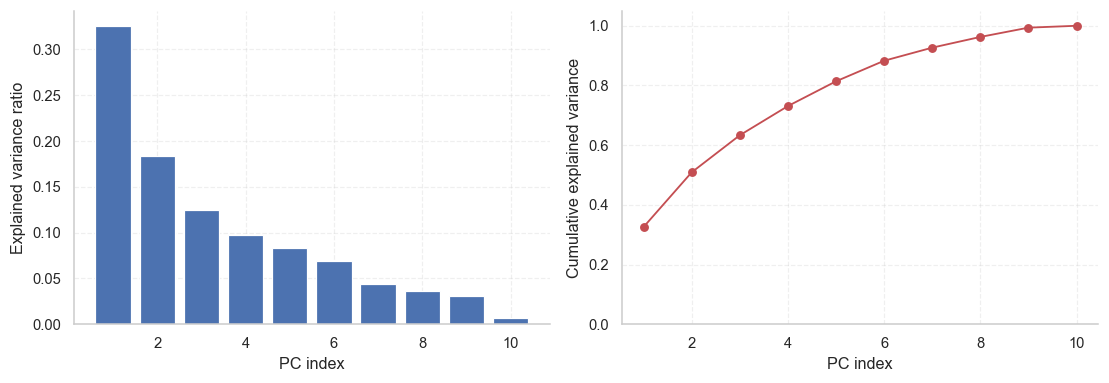

,PC1,PC2,PC3,PC4
n_points,-0.076976,0.310855,0.499682,0.011219
time_span_days,-0.105095,0.389411,0.466658,-0.173057
cadence_minutes,-0.035120,-0.104124,-0.150943,-0.132844
log_flux_median,-0.310822,0.428619,-0.096733,-0.215587
log_flux_std,-0.303745,0.448807,-0.047260,0.144812
log_flux_cv,0.001072,0.072081,0.116442,0.873924
prot,0.464225,0.185291,0.046960,-0.127692
teff,-0.307165,0.150150,-0.409886,-0.179151
prot_label,0.464225,0.185291,0.046960,-0.127692
prot_ls,0.162773,0.295496,-0.440578,0.141567


In [15]:
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_imputed = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imputed)

pca = PCA(n_components=min(10, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6))
axes[0].bar(range(1, len(explained) + 1), explained, color=PALETTE[0])
axes[0].set_xlabel('PC index')
axes[0].set_ylabel('Explained variance ratio')

axes[1].plot(range(1, len(explained) + 1), np.cumsum(explained), marker='o', color=PALETTE[2])
axes[1].set_xlabel('PC index')
axes[1].set_ylabel('Cumulative explained variance')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca.components_.T,
    index=selected_features,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
)
loadings.iloc[:, :4]


## PCA scatter view

Color by `prot` (or other variable if available).


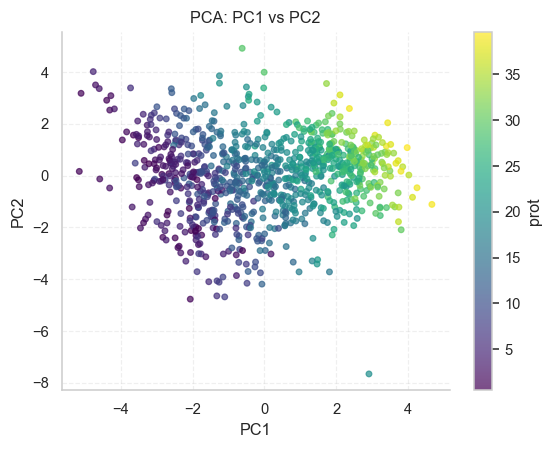

In [16]:
plot_color = 'prot' if 'prot' in df.columns else None

plt.figure(figsize=(5.2, 4.2))
if plot_color:
    sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df[plot_color], s=14, alpha=0.7, cmap='viridis')
    cbar = plt.colorbar(sc)
    cbar.set_label(plot_color)
else:
    plt.scatter(X_pca[:, 0], X_pca[:, 1], s=14, alpha=0.7, color=PALETTE[0])

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.tight_layout()
plt.show()


## KMeans clustering on PCA space

Select k by silhouette and Davies-Bouldin scores.


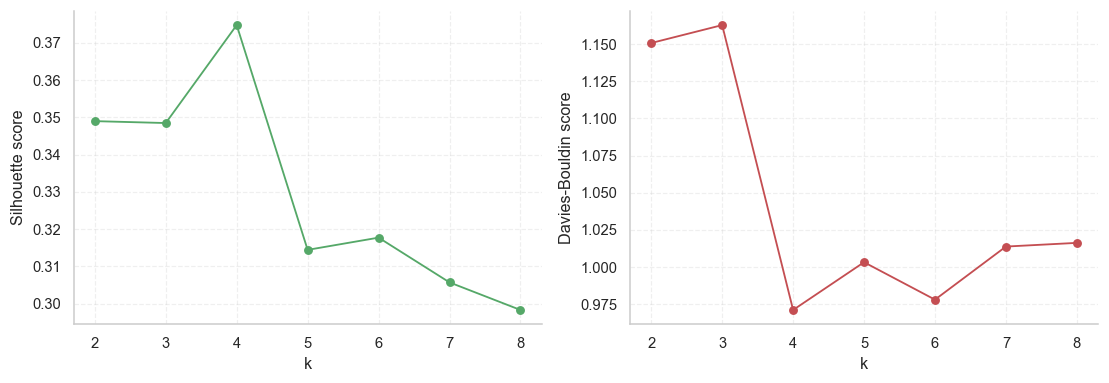

Best k by silhouette: 4


In [17]:
max_k = 8
ks = list(range(2, max_k + 1))

sil_scores = []
db_scores = []
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE)
    labels = kmeans.fit_predict(X_pca[:, :3])
    inertias.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_pca[:, :3], labels))
    db_scores.append(davies_bouldin_score(X_pca[:, :3], labels))

fig, axes = plt.subplots(1, 2, figsize=(10.2, 3.6))
axes[0].plot(ks, sil_scores, marker='o', color=PALETTE[1])
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette score')

axes[1].plot(ks, db_scores, marker='o', color=PALETTE[2])
axes[1].set_xlabel('k')
axes[1].set_ylabel('Davies-Bouldin score')

plt.tight_layout()
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
print('Best k by silhouette:', best_k)

kmeans = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE)
cluster_labels = kmeans.fit_predict(X_pca[:, :3])


## Cluster visualization


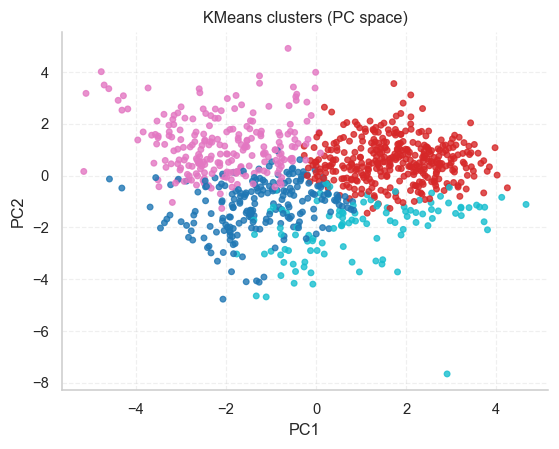

In [18]:
plt.figure(figsize=(5.2, 4.2))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, s=14, alpha=0.8, cmap='tab10')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans clusters (PC space)')
plt.tight_layout()
plt.show()


## Cluster profiles

Summarize feature means per cluster to interpret group differences.


In [19]:
profile = df[selected_features].copy()
profile['cluster'] = cluster_labels

cluster_summary = profile.groupby('cluster').mean(numeric_only=True)
cluster_summary


,n_points,time_span_days,cadence_minutes,log_flux_median,log_flux_std,log_flux_cv,prot,teff,prot_label,prot_ls,prot_gps,prot_qpgp
cluster,,,,,,,,,,,,
0,62449.113744,1452.221892,29.424431,4.217017,2.705855,-1.511162,9.903175,5080.924171,9.903175,22.638702,11.228615,11.033709
1,61830.420168,1454.112951,29.424398,4.140051,2.625180,-1.514872,25.210936,4867.899160,25.210936,38.265077,28.625660,32.741841
2,62305.767241,1463.309369,29.424435,4.870554,3.333042,-1.537512,9.150927,5928.883621,9.150927,37.752347,27.006784,10.778370
3,52025.761468,1269.504286,29.424526,3.927389,2.393367,-1.534022,17.093440,5241.119266,17.093440,37.845874,24.202909,21.542859


## Optional: Gaussian Mixture Model (GMM)

A probabilistic alternative to KMeans for narrative comparison.


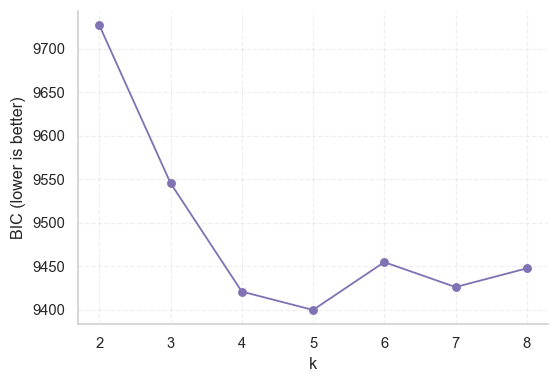

In [20]:
max_k = 8
ks = list(range(2, max_k + 1))

bics = []
for k in ks:
    gmm = GaussianMixture(n_components=k, random_state=RANDOM_STATE)
    gmm.fit(X_pca[:, :3])
    bics.append(gmm.bic(X_pca[:, :3]))

plt.figure(figsize=(5.2, 3.6))
plt.plot(ks, bics, marker='o', color=PALETTE[3])
plt.xlabel('k')
plt.ylabel('BIC (lower is better)')
plt.tight_layout()
plt.show()
